Estimating Mean Radiant Temperature from LST and shadows at a precise moment, at 1m scale

MRT = (LST + 10.2)/0.92 x (1-0.5 x 1shadows)

### General paths, libraries

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import CRS
import pandas as pd
from rasterio import features
from rasterio.transform import from_origin
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
from rasterstats import zonal_stats
import os

In [2]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'
census_areas_name = ''
city_boundary = 'cba_boundary.gpkg'

trees_shadows_name = 'shadows_trees_2024-01-17_140833.gpkg'
building_shadows_name = 'shadows_buildings_2024-01-17_140833.gpkg'
other_shadows_name = ''
crs_epsg = 32720  # Projected CRS EPSG code, depending on the city

In [3]:
# derived paths
shadows_vector_path = os.path.join(base_dir, 'MRT-prediction/shadows_all_2024-08-09-095810.gpkg')
shadow_raster_path = os.path.join(base_dir, 'MRT-prediction/shadows_all_2024-08-09-095810_1m.tif')  
lst_predicted_path = os.path.join(base_dir, 'LST-prediction/LST_predicted_RF.tif') 
lst_predicted_1m_path = os.path.join(base_dir, 'LST-prediction/LST_predicted_1m.tif')
mrt_output_path = os.path.join(base_dir, 'MRT-prediction/MRT_1m.tif')
census_areas_path = os.path.join(base_dir, 'vectors/',census_areas_name)
bound_path = os.path.join(base_dir, 'vectors/',city_boundary)

### Preparing shadows (rasterizing-1m)

In [ ]:
shadow1 = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/shadows/', building_shadows_name)) 
shadow1 = shadow1.to_crs(CRS.from_epsg(crs_epsg))
shadow2 = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/shadows/', trees_shadows_name)) 
shadow2 = shadow2.to_crs(CRS.from_epsg(crs_epsg))
#shadow3 = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/shadows/', other_shadows_name)) 
#shadow3 = shadow3.to_crs(CRS.from_epsg(crs_epsg))

# join all the shadow files in one -- 
shadow = gpd.GeoDataFrame(pd.concat([shadow1, shadow2], ignore_index=True), crs=shadow1.crs)

#preparing dataset for rasterizing -- 3m aprox
shadow = shadow[~shadow.geometry.is_empty] # Drop empty geometries
shadow = shadow[shadow.geometry.notnull()] # Drop null geometries
shadow["geometry"] = shadow.buffer(0) # Fix invalid geometries (buffer(0) trick)
shadow = shadow[~shadow.geometry.is_empty] # Drop again if something became empty

# clip to city boundary
# we computed the shadows including trees in a 100m offset of the city boundary, 
# now we clip the shadows that fit into the city boundary
boundary = gpd.read_file(bound_path)
boundary = boundary.to_crs(shadow.crs)
shadow = shadow.clip(boundary) 

shadow.to_file(shadows_vector_path, layer="shadow", driver="GPKG")
del shadow1, shadow2



In [ ]:
#rasterizing 
shadow = gpd.read_file(shadows_vector_path)

res = 1  # pixel size in meters
minx, miny, maxx, maxy = shadow.total_bounds # bounds of the vector layer

# number of rows and cols
width  = int((maxx - minx) / res)
height = int((maxy - miny) / res)

# affine transform (top-left origin)
transform = from_origin(minx, maxy, res, res)

# geometry -> value (burn = 1)
shapes = ((geom, 1) for geom in shadow.geometry if geom is not None)

# rasterization
raster = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

# Save raster
with rasterio.open(
    shadow_raster_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=raster.dtype,
    crs=shadow.crs,
    transform=transform
) as dst:
    dst.write(raster, 1)
    
del shadow, shapes, raster


In [11]:
with rasterio.open(shadow_raster_path) as src:
    shadow_raster = src.read(1)        
    transform = src.transform  
    crs = src.crs              

### Upscaling modeled LST to shadow resolution (1m)

In [17]:
with rasterio.open(shadow_raster_path) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

with rasterio.open(lst_predicted_path) as src:
    lst_1m = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=lst_1m,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.bilinear  # good for continuous variables like LST
    )

    meta = src.meta.copy()
    meta.update({
        "height": ref_shape[0],
        "width": ref_shape[1],
        "transform": ref_transform,
        "crs": ref_crs,
        "dtype": "float32"
    })

    with rasterio.open(lst_predicted_1m_path, "w", **meta) as dst:
        dst.write(lst_1m, 1)

### MRT estimation


In [19]:
with rasterio.open(lst_predicted_1m_path) as lst, rasterio.open(shadow_raster_path) as sh:
    
    # Read data as float
    lst_arr = lst.read(1).astype("float32")
    sh_arr  = sh.read(1).astype("float32")
    
    # MRT formula
    mrt = ((lst_arr + 10.2) / 0.92) - 10 * sh_arr

    # Metadata from LST
    meta = lst.meta.copy()
    meta.update(dtype="float32", nodata=np.nan)

    # Save raster
    with rasterio.open(mrt_output_path, "w", **meta) as dst:
        dst.write(mrt, 1)


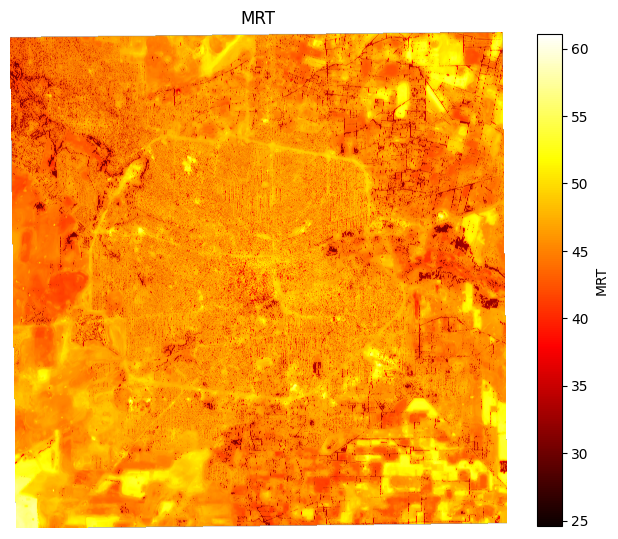

In [ ]:
with rasterio.open(mrt_output_path) as src: #complete image, 6 minutes aprox
    mrt_plot = src.read(1) 

plt.figure(figsize=(8,8)) 
img = plt.imshow(mrt_plot, cmap="hot_r", origin="upper") 
plt.colorbar(img, shrink=0.8, label="MRT")
plt.axis("off")
plt.title("MRT")
plt.show()


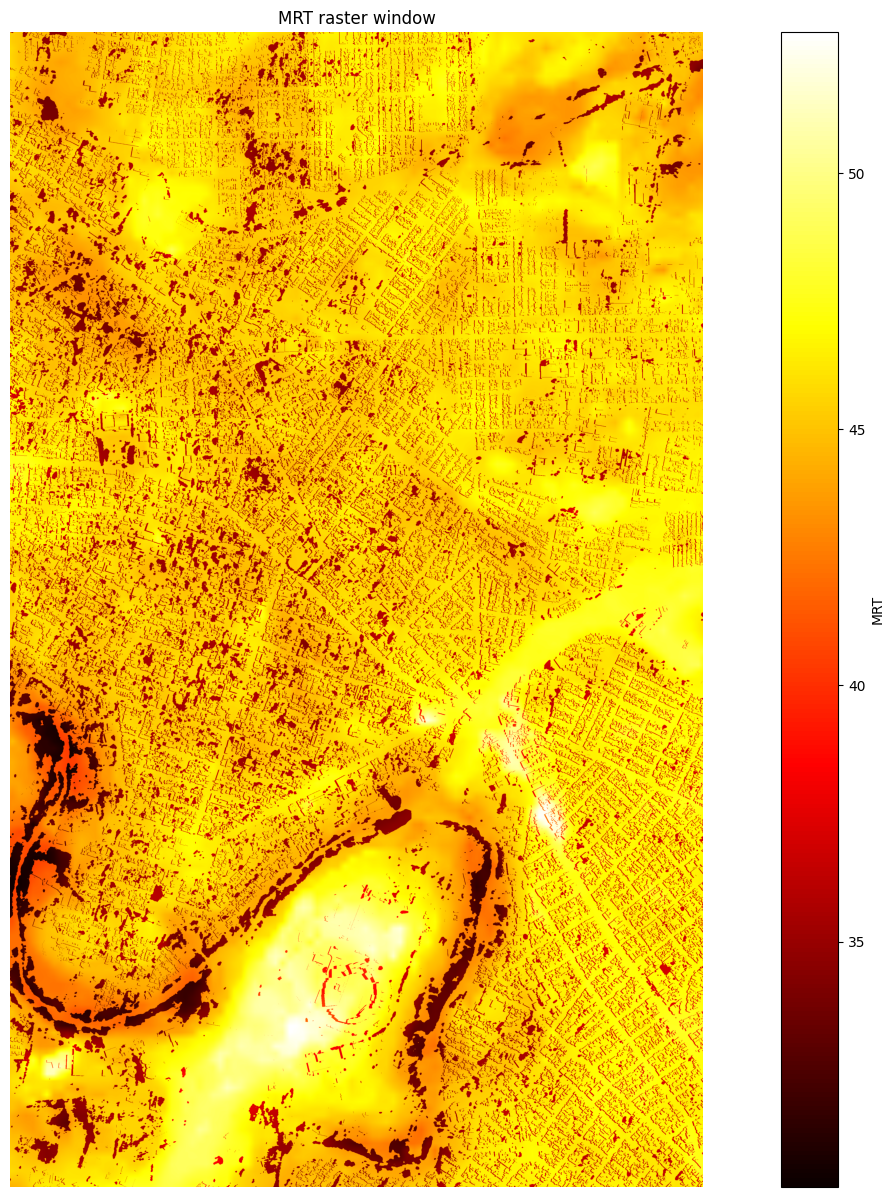

In [40]:
# print of a window of the raster


with rasterio.open(mrt_output_path) as src:
    mrt_1m = src.read(1)

xmin, ymin = 380000, 6528000
xmax, ymax = 383000, 6533000

# Convert bounds to pixel window
win = from_bounds(xmin, ymin, xmax, ymax, transform)

# Slices
r0, c0 = int(win.row_off), int(win.col_off)
r1 = r0 + int(win.height)
c1 = c0 + int(win.width)

# Extract window
r_win = mrt_1m[r0:r1, c0:c1]

# Plot
plt.figure(figsize=(20,15))
plt.imshow(r_win, cmap="hot", origin="upper")
plt.title("MRT raster window")
plt.colorbar(label="MRT") 
plt.axis("off")
plt.show()

